In [2]:
import numpy as np
import matplotlib.pyplot as plt

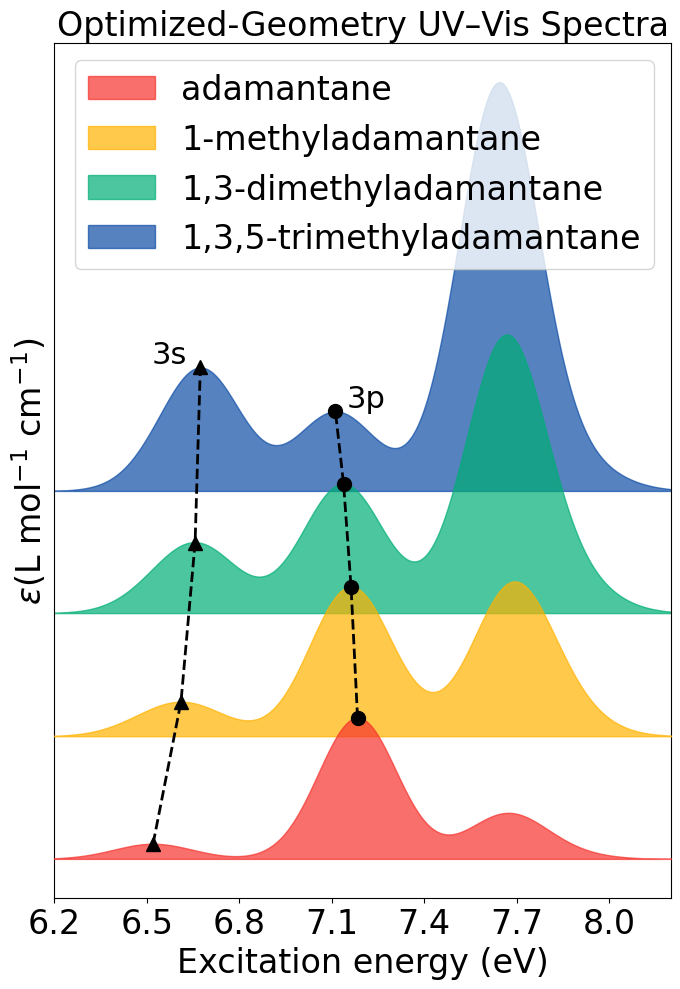

In [3]:
file_paths = [
    '0spectrum_curve.txt',
    '1spectrum_curve.txt',
    '2spectrum_curve.txt',
    '3spectrum_curve.txt'
]

colors = ['#F6322D', '#FFB300', '#00AE75', '#0E4DA6']
legend_labels = [
    'adamantane',
    '1-methyladamantane',
    '1,3-dimethyladamantane',
    '1,3,5-trimethyladamantane'
]

x_shifts = [0.0, 0.0, 0.0, 0.0]
distance_between_mountains = 90000

all_ymax = []
for fp in file_paths:
    data = np.loadtxt(fp, skiprows=1)
    all_ymax.append(np.max(data[:, 1] * 200000))
global_ymax = max(all_ymax)

delta = 0.3 * global_ymax

per_trace_offset = [
    0.0,
    1.0 * delta,
    2.0 * delta,
    3.0 * delta
]

plt.figure(figsize=(7, 10))

y_offset = 0.0
height_factor = 1.0

peak_points_64_67 = []
peak_points_70_73 = []

for idx, (file_path, color, label, x_shift) in enumerate(
        zip(file_paths, colors, legend_labels, x_shifts)):

    data = np.loadtxt(file_path, skiprows=1)
    data[:, 1] *= 200000
    data[:, 0] += x_shift

    x = data[:, 0]
    y = data[:, 1] * height_factor

    current_offset = y_offset + per_trace_offset[idx]

    # 6.0–6.7 eV
    mask_64_67 = (x >= 6.0) & (x <= 6.7)
    if np.any(mask_64_67):
        xr = x[mask_64_67]
        yr = y[mask_64_67]
        peak_points_64_67.append((xr[np.argmax(yr)], yr.max() + current_offset))

    # 7.0–7.3 eV
    mask_70_73 = (x >= 7.0) & (x <= 7.3)
    if np.any(mask_70_73):
        xr = x[mask_70_73]
        yr = y[mask_70_73]
        peak_points_70_73.append((xr[np.argmax(yr)], yr.max() + current_offset))

    plt.fill_between(
        x, current_offset, y + current_offset,
        label=label, alpha=0.7,
        zorder=len(file_paths) - idx,
        color=color
    )

    y_offset += distance_between_mountains


CYAN = 'black'   

# ---- 3s ----
if len(peak_points_64_67) > 1:
    pts = np.array(peak_points_64_67)
    plt.plot(pts[:, 0], pts[:, 1],
             linestyle='--', color=CYAN, linewidth=2,
             zorder=len(file_paths) + 10)

for px, py in peak_points_64_67:
    plt.plot(px, py,
             marker='^', linestyle='None',
             color=CYAN, markersize=10,
             zorder=len(file_paths) + 11)

if peak_points_64_67:
    px, py = peak_points_64_67[-1]
    plt.text(px - 0.1, py + 0.01 * global_ymax,
             '3s', fontsize=22, ha='center')


if len(peak_points_70_73) > 1:
    pts = np.array(peak_points_70_73)
    plt.plot(pts[:, 0], pts[:, 1],
             color='black', linestyle='--', linewidth=2,
             zorder=len(file_paths) + 10)

for px, py in peak_points_70_73:
    plt.plot(px, py, 'o', color='black', markersize=10,
             zorder=len(file_paths) + 11)

if peak_points_70_73:
    px, py = peak_points_70_73[-1]
    plt.text(px + 0.1, py + 0.01 * global_ymax,
             '3p', fontsize=22, ha='center')


plt.xlim(6.2, 8.2)
plt.xticks(np.arange(6.2, 8.1, 0.3), fontsize=24)
plt.title('Optimized-Geometry UV–Vis Spectra', fontsize=24)
plt.xlabel('Excitation energy (eV)', fontsize=24)
plt.ylabel(r'$\varepsilon$(L mol$^{-1}$ cm$^{-1}$)', fontsize=24)

plt.legend(fontsize=24)
plt.yticks([])

plt.tight_layout()
plt.savefig('finalopt_newcolor.png', dpi=600)
plt.show()
